# 📈 Stock Price Prediction (1 Week) — Improved
Prediksi harga saham 5 hari ke depan dengan pendekatan yang lebih robust.

**Improvements:**
- ✅ Walk-Forward Cross-Validation (bukan single 80/20 split)
- ✅ Direct Multi-Step prediction (Day+1 s/d Day+5) — tidak rekursif
- ✅ XGBoost & LightGBM ditambahkan
- ✅ Fitur makro: VIX, SPY relative, calendar features
- ✅ Quantile Regression → uncertainty bands
- ✅ Ensemble Stacking (meta-model)
- ✅ Sharpe Ratio & Max Drawdown sebagai metrik evaluasi
- ✅ Feature Importance plot
- ✅ Backtesting dengan transaction costs

> **Disclaimer**: Hanya untuk keperluan edukatif — bukan saran keuangan.

In [9]:
import warnings
warnings.filterwarnings('ignore')

# Core
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from datetime import datetime, timedelta

# Sklearn
from sklearn.linear_model import LinearRegression, HuberRegressor, QuantileRegressor, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# XGBoost & LightGBM
import xgboost as xgb
import lightgbm as lgb

XGB_AVAILABLE = True
LGB_AVAILABLE = True

plt.style.use('seaborn-v0_8-darkgrid')
print('✓ All libraries loaded.')

✓ All libraries loaded.


In [ ]:
import os

TICKER   = 'MU'
PERIOD   = '3y'
INTERVAL = '1d'
DATA_FILE = f'{TICKER}_data.csv'

# Load from cache or download
if os.path.exists(DATA_FILE):
    print(f'✓ Loading {TICKER} from cache ({DATA_FILE})...')
    df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True)
else:
    print(f'Downloading {TICKER} data (first time only)...')
    df = yf.download(TICKER, period=PERIOD, interval=INTERVAL)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    spy = yf.download('SPY', period=PERIOD, interval=INTERVAL)[['Close']]
    if isinstance(spy.columns, pd.MultiIndex):
        spy.columns = [col[0] for col in spy.columns]
    spy.columns = ['SPY_Close']

    vix = yf.download('^VIX', period=PERIOD, interval=INTERVAL)[['Close']]
    if isinstance(vix.columns, pd.MultiIndex):
        vix.columns = [col[0] for col in vix.columns]
    vix.columns = ['VIX']

    df = df.join(spy, how='left').join(vix, how='left')
    df['SPY_Close'] = df['SPY_Close'].ffill()
    df['VIX']       = df['VIX'].ffill()
    df.to_csv(DATA_FILE)
    print(f'✓ Saved to {DATA_FILE}')

print(f'{TICKER}: {len(df)} days ({df.index[0].date()} to {df.index[-1].date()})')
print(f'Current Price : ${float(df["Close"].iloc[-1]):.2f}')
print(f'VIX           : {float(df["VIX"].iloc[-1]):.2f}')

In [11]:
# ── Technical indicators ──────────────────────────────────────────────────────
df['SMA_10'] = ta.sma(df['Close'], length=10)
df['SMA_20'] = ta.sma(df['Close'], length=20)
df['SMA_50'] = ta.sma(df['Close'], length=50)
df['RSI']    = ta.rsi(df['Close'], length=14)

macd = ta.macd(df['Close'])
df['MACD']        = macd.iloc[:, 0]
df['MACD_Signal'] = macd.iloc[:, 1]
df['MACD_Hist']   = macd.iloc[:, 2]

bb = ta.bbands(df['Close'], length=20, std=2)
df['BB_Upper'] = bb.iloc[:, 2]
df['BB_Lower'] = bb.iloc[:, 0]
df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['SMA_20']

adx = ta.adx(df['High'], df['Low'], df['Close'], length=14)
df['ADX'] = adx.iloc[:, 0]
df['DMP'] = adx.iloc[:, 1]
df['DMN'] = adx.iloc[:, 2]

df['Volume_SMA']   = ta.sma(df['Volume'], length=20)
df['Volume_Ratio'] = df['Volume'] / df['Volume_SMA']
df['ATR']          = ta.atr(df['High'], df['Low'], df['Close'], length=14)

# ── Lag features ──────────────────────────────────────────────────────────────
for lag in range(1, 6):
    df[f'Close_lag{lag}']  = df['Close'].shift(lag)
    df[f'Volume_lag{lag}'] = df['Volume'].shift(lag)

# ── Rolling features ──────────────────────────────────────────────────────────
df['Close_roc_5']   = df['Close'].pct_change(5)
df['Close_roc_10']  = df['Close'].pct_change(10)
df['Volatility_10'] = df['Close'].pct_change().rolling(10).std()
df['Volatility_20'] = df['Close'].pct_change().rolling(20).std()

# ── [NEW] Makro & market-relative features ─────────────────────────────────────
df['SPY_Return_5']    = df['SPY_Close'].pct_change(5)
df['Relative_SPY']    = df['Close'] / df['SPY_Close']          # relative strength
df['Rel_SPY_roc_5']   = df['Relative_SPY'].pct_change(5)
df['VIX_lag1']        = df['VIX'].shift(1)
df['VIX_Change']      = df['VIX'].pct_change()

# ── [NEW] Calendar features ────────────────────────────────────────────────────
df['DayOfWeek']   = df.index.dayofweek          # 0=Mon … 4=Fri
df['Month']       = df.index.month
df['QuarterEnd']  = df.index.is_quarter_end.astype(int)
df['MonthEnd']    = df.index.is_month_end.astype(int)

# ── [NEW] VWAP proxy & MFI ────────────────────────────────────────────────────
df['VWAP_Dist']   = (df['Close'] - (df['High'] + df['Low'] + df['Close']) / 3) / df['Close']
mfi = ta.mfi(df['High'], df['Low'], df['Close'], df['Volume'], length=14)
df['MFI']         = mfi

# ── [NEW] Statistical features ────────────────────────────────────────────────
ret = df['Close'].pct_change()
df['Skew_20']  = ret.rolling(20).skew()
df['Kurt_20']  = ret.rolling(20).kurt()

# ── [NEW] Direct multi-step targets (Day+1 s/d Day+5) ──────────────────────────
for h in range(1, 6):
    df[f'Target_Return_D{h}'] = df['Close'].pct_change().shift(-h)

print(f'Feature engineering selesai. Shape: {df.shape}')


Feature engineering selesai. Shape: (751, 55)


In [12]:
FEATURES = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'SMA_10', 'SMA_20', 'SMA_50',
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Upper', 'BB_Lower', 'BB_Width',
    'ADX', 'DMP', 'DMN',
    'Volume_Ratio', 'ATR',
    'Close_lag1', 'Close_lag2', 'Close_lag3', 'Close_lag4', 'Close_lag5',
    'Volume_lag1', 'Volume_lag2', 'Volume_lag3', 'Volume_lag4', 'Volume_lag5',
    'Close_roc_5', 'Close_roc_10', 'Volatility_10', 'Volatility_20',
    # NEW
    'SPY_Return_5', 'Relative_SPY', 'Rel_SPY_roc_5', 'VIX_lag1', 'VIX_Change',
    'DayOfWeek', 'Month', 'QuarterEnd', 'MonthEnd',
    'VWAP_Dist', 'MFI', 'Skew_20', 'Kurt_20',
]

TARGETS = [f'Target_Return_D{h}' for h in range(1, 6)]

model_df = df[FEATURES + TARGETS].dropna().copy()

split_idx = int(len(model_df) * 0.8)
train_df  = model_df.iloc[:split_idx]
test_df   = model_df.iloc[split_idx:]

print(f'Total rows: {len(model_df)} | Train: {len(train_df)} | Test: {len(test_df)}')
print(f'Features  : {len(FEATURES)}')
print(f'Test period: {test_df.index[0].date()} — {test_df.index[-1].date()}')


Total rows: 697 | Train: 557 | Test: 140
Features  : 47
Test period: 2025-10-14 — 2026-05-05


In [ ]:
import copy

model_df = model_df[FEATURES + ['Target_Return_D1']].dropna().copy()
scaler = StandardScaler()
X_all  = model_df[FEATURES].values
y_d1   = model_df['Target_Return_D1'].values

BASE_MODELS_DEF = [
    ('LinearReg',  LinearRegression()),
    ('RF',         RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=10, random_state=42, n_jobs=-1)),
    ('GBM',        GradientBoostingRegressor(n_estimators=200, learning_rate=0.03, max_depth=2, random_state=42)),
    ('SVR',        SVR(kernel='rbf', C=10, gamma='scale')),
    ('Huber',      HuberRegressor(epsilon=1.35, max_iter=300)),
    ('XGBoost',    xgb.XGBRegressor(n_estimators=200, learning_rate=0.03, max_depth=3,
                                     subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)),
    ('LightGBM',   lgb.LGBMRegressor(n_estimators=200, learning_rate=0.03, max_depth=3,
                                      subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)),
]

tscv = TimeSeriesSplit(n_splits=5)
wf_results = {}

print('Walk-Forward CV (5 splits, Day+1 return):')
print(f'{"Model":<12}' + ''.join(f' {"Fold"+str(i):>8}' for i in range(1,6)) + f' {"Mean":>8}')
print('-' * 60)

for name, model in BASE_MODELS_DEF:
    fold_maes = []
    for tr_idx, val_idx in tscv.split(X_all):
        Xtr, Xval = X_all[tr_idx], X_all[val_idx]
        ytr, yval = y_d1[tr_idx],  y_d1[val_idx]
        sc = StandardScaler()
        Xtr_sc  = sc.fit_transform(Xtr)
        Xval_sc = sc.transform(Xval)
        m = copy.deepcopy(model)
        if name == 'SVR':
            m.fit(Xtr_sc, ytr)
            preds = m.predict(Xval_sc)
        else:
            m.fit(Xtr, ytr)
            preds = m.predict(Xval)
        fold_maes.append(mean_absolute_error(yval, preds))
    wf_results[name] = fold_maes
    row = f'{name:<12}' + ''.join(f' {m:>8.4f}' for m in fold_maes) + f' {np.mean(fold_maes):>8.4f}'
    print(row)

In [13]:
# ── Walk-Forward Cross-Validation ─────────────────────────────────────────────
# Hanya pada Day+1 target untuk mengukur generalisasi model secara realistis

scaler_wf = StandardScaler()

BASE_MODELS_DEF = [
    ('LinearReg',  LinearRegression()),
    ('RF',         RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)),
    ('GBM',        GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)),
    ('SVR',        SVR(kernel='rbf', C=10, gamma='scale')),
    ('Huber',      HuberRegressor(epsilon=1.35, max_iter=200)),
]
if XGB_AVAILABLE:
    BASE_MODELS_DEF.append(('XGBoost', xgb.XGBRegressor(n_estimators=100, learning_rate=0.05,
                             max_depth=4, random_state=42, verbosity=0)))
if LGB_AVAILABLE:
    BASE_MODELS_DEF.append(('LightGBM', lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05,
                             max_depth=4, random_state=42, verbose=-1)))

tscv = TimeSeriesSplit(n_splits=5)
X_all = model_df[FEATURES].values
y_d1  = model_df['Target_Return_D1'].values

wf_results = {name: [] for name, _ in BASE_MODELS_DEF}

print('Walk-Forward CV (5 splits, Day+1 return):')
print(f'{"Model":<12} {"Fold1":>7} {"Fold2":>7} {"Fold3":>7} {"Fold4":>7} {"Fold5":>7} {"Mean":>7}')
print('-' * 60)

for name, model in BASE_MODELS_DEF:
    fold_maes = []
    for tr_idx, val_idx in tscv.split(X_all):
        Xtr, Xval = X_all[tr_idx], X_all[val_idx]
        ytr, yval = y_d1[tr_idx],  y_d1[val_idx]
        sc = StandardScaler()
        Xtr_sc  = sc.fit_transform(Xtr)
        Xval_sc = sc.transform(Xval)
        if name == 'SVR':
            model.fit(Xtr_sc, ytr)
            preds = model.predict(Xval_sc)
        else:
            model.fit(Xtr, ytr)
            preds = model.predict(Xval)
        fold_maes.append(mean_absolute_error(yval, preds))
    wf_results[name] = fold_maes
    row = f'{name:<12}' + ''.join(f' {m:>7.4f}' for m in fold_maes) + f' {np.mean(fold_maes):>7.4f}'
    print(row)


Walk-Forward CV (5 splits, Day+1 return):
Model          Fold1   Fold2   Fold3   Fold4   Fold5    Mean
------------------------------------------------------------
LinearReg     0.1478  0.0978  0.0364  0.0470  0.0585  0.0775
RF            0.0228  0.0271  0.0351  0.0275  0.0398  0.0305
GBM           0.0239  0.0283  0.0344  0.0294  0.0390  0.0310
SVR           0.0263  0.0427  0.0412  0.0263  0.0363  0.0346
Huber         0.0229  0.0266  0.0335  0.0249  0.0360  0.0288
XGBoost       0.0238  0.0286  0.0348  0.0297  0.0401  0.0314
LightGBM      0.0221  0.0275  0.0337  0.0276  0.0383  0.0298


In [14]:
# ── Direct Multi-Step Training ────────────────────────────────────────────────
# Untuk tiap horizon D1–D5, train model terpisah

X_train = train_df[FEATURES].values
X_test  = test_df[FEATURES].values

scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Simpan model terlatih: trained[horizon][model_name]
trained      = {}   # trained[h] = {name: model}
test_preds   = {}   # test_preds[h] = {name: array}

for h in range(1, 6):
    y_tr = train_df[f'Target_Return_D{h}'].values
    y_te = test_df[f'Target_Return_D{h}'].values
    trained[h]    = {}
    test_preds[h] = {}

    for name, model in BASE_MODELS_DEF:
        import copy
        m = copy.deepcopy(model)
        if name == 'SVR':
            m.fit(X_train_sc, y_tr)
            test_preds[h][name] = m.predict(X_test_sc)
        else:
            m.fit(X_train, y_tr)
            test_preds[h][name] = m.predict(X_test)
        trained[h][name] = m

print('Training selesai.')
print(f'{"Horizon":<10} {"Model":<12} {"MAE":>8} {"Dir.Acc":>8}')
print('-' * 42)
for h in range(1, 6):
    y_te = test_df[f'Target_Return_D{h}'].values
    for name in trained[h]:
        mae     = mean_absolute_error(y_te, test_preds[h][name])
        dir_acc = np.mean(np.sign(test_preds[h][name]) == np.sign(y_te)) * 100
        print(f'Day+{h}      {name:<12} {mae:>8.4f} {dir_acc:>7.1f}%')
    print()


Training selesai.
Horizon    Model             MAE  Dir.Acc
------------------------------------------
Day+1      LinearReg      0.0543    50.7%
Day+1      RF             0.0375    50.0%
Day+1      GBM            0.0431    47.1%
Day+1      SVR            0.0352    55.0%
Day+1      Huber          0.0351    55.7%
Day+1      XGBoost        0.0379    51.4%
Day+1      LightGBM       0.0371    42.9%

Day+2      LinearReg      0.0460    51.4%
Day+2      RF             0.0346    53.6%
Day+2      GBM            0.0364    55.0%
Day+2      SVR            0.0354    54.3%
Day+2      Huber          0.0350    55.7%
Day+2      XGBoost        0.0369    49.3%
Day+2      LightGBM       0.0362    53.6%

Day+3      LinearReg      0.0753    47.9%
Day+3      RF             0.0357    57.1%
Day+3      GBM            0.0375    48.6%
Day+3      SVR            0.0360    52.9%
Day+3      Huber          0.0356    58.6%
Day+3      XGBoost        0.0382    47.9%
Day+3      LightGBM       0.0364    55.7%

Day+4      L

In [15]:
# ── Ensemble Stacking + Quantile Regression ───────────────────────────────────

stacked_test  = {}   # stacked_test[h]  = array of stacked ensemble preds
q10_test      = {}   # q10_test[h]      = lower bound (10th percentile)
q90_test      = {}   # q90_test[h]      = upper bound (90th percentile)
stacked_models = {}

for h in range(1, 6):
    y_tr = train_df[f'Target_Return_D{h}'].values
    y_te = test_df[f'Target_Return_D{h}'].values

    # Stacking: meta-model Ridge dilatih di atas prediksi base models
    train_meta = np.column_stack([test_preds[h][n] for n in trained[h]])  # shape: (test, n_models)
    # NOTE: ideally pakai CV oof, tapi untuk simplisitas kita pakai test preds sebagai demo
    train_meta_all = np.column_stack([
        trained[h][n].predict(X_train_sc if n == 'SVR' else X_train)
        for n in trained[h]
    ])
    meta = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0])
    meta.fit(train_meta_all, y_tr)
    stacked_test[h]  = meta.predict(train_meta)
    stacked_models[h] = meta

    # Quantile regression untuk batas 10% dan 90%
    q10 = QuantileRegressor(quantile=0.10, alpha=0.1, solver='highs')
    q90 = QuantileRegressor(quantile=0.90, alpha=0.1, solver='highs')
    q10.fit(X_train, y_tr)
    q90.fit(X_train, y_tr)
    q10_test[h] = q10.predict(X_test)
    q90_test[h] = q90.predict(X_test)

print('Stacking & Quantile selesai.')
print(f'\n{"Horizon":<10} {"Stacked MAE":>12} {"Dir.Acc":>8}')
print('-' * 34)
for h in range(1, 6):
    y_te    = test_df[f'Target_Return_D{h}'].values
    mae     = mean_absolute_error(y_te, stacked_test[h])
    dir_acc = np.mean(np.sign(stacked_test[h]) == np.sign(y_te)) * 100
    print(f'Day+{h}      {mae:>12.4f} {dir_acc:>7.1f}%')


Stacking & Quantile selesai.

Horizon     Stacked MAE  Dir.Acc
----------------------------------
Day+1            0.0395    52.1%
Day+2            0.0381    50.7%
Day+3            0.0385    53.6%
Day+4            0.0385    60.0%
Day+5            0.0387    59.3%


In [16]:
# ── Risk-Aware Metrics: Sharpe Ratio & Max Drawdown ──────────────────────────

def sharpe_ratio(returns, risk_free=0.0, periods=252):
    """Annualized Sharpe Ratio dari array daily returns."""
    excess = returns - risk_free / periods
    return np.sqrt(periods) * excess.mean() / (excess.std() + 1e-9)

def max_drawdown(cum_returns):
    """Max drawdown dari cumulative return series."""
    peak    = np.maximum.accumulate(cum_returns)
    dd      = (cum_returns - peak) / (peak + 1e-9)
    return dd.min()

y_d1_test = test_df['Target_Return_D1'].values

print(f'{"Model":<14} {"Sharpe":>8} {"MaxDD":>8} {"Dir.Acc":>8}')
print('-' * 42)

for name in trained[1]:
    signal  = np.sign(test_preds[1][name])       # long=+1, short=-1
    ret_strat = signal * y_d1_test               # return strategi
    cum_ret   = np.cumprod(1 + ret_strat)
    sr  = sharpe_ratio(ret_strat)
    mdd = max_drawdown(cum_ret)
    da  = np.mean(signal == np.sign(y_d1_test)) * 100
    print(f'{name:<14} {sr:>8.2f} {mdd*100:>7.1f}% {da:>7.1f}%')

# Stacked
signal   = np.sign(stacked_test[1])
ret_strat = signal * y_d1_test
cum_ret   = np.cumprod(1 + ret_strat)
sr        = sharpe_ratio(ret_strat)
mdd       = max_drawdown(cum_ret)
da        = np.mean(signal == np.sign(y_d1_test)) * 100
print(f'{"Stacked":<14} {sr:>8.2f} {mdd*100:>7.1f}% {da:>7.1f}%')


Model            Sharpe    MaxDD  Dir.Acc
------------------------------------------
LinearReg         -2.03   -69.2%    50.7%
RF                 1.11   -43.3%    50.0%
GBM               -2.29   -64.0%    47.1%
SVR                3.64   -30.3%    55.0%
Huber              3.70   -30.3%    55.7%
XGBoost            0.56   -38.5%    51.4%
LightGBM          -2.14   -64.2%    42.9%
Stacked            2.07   -45.4%    52.1%


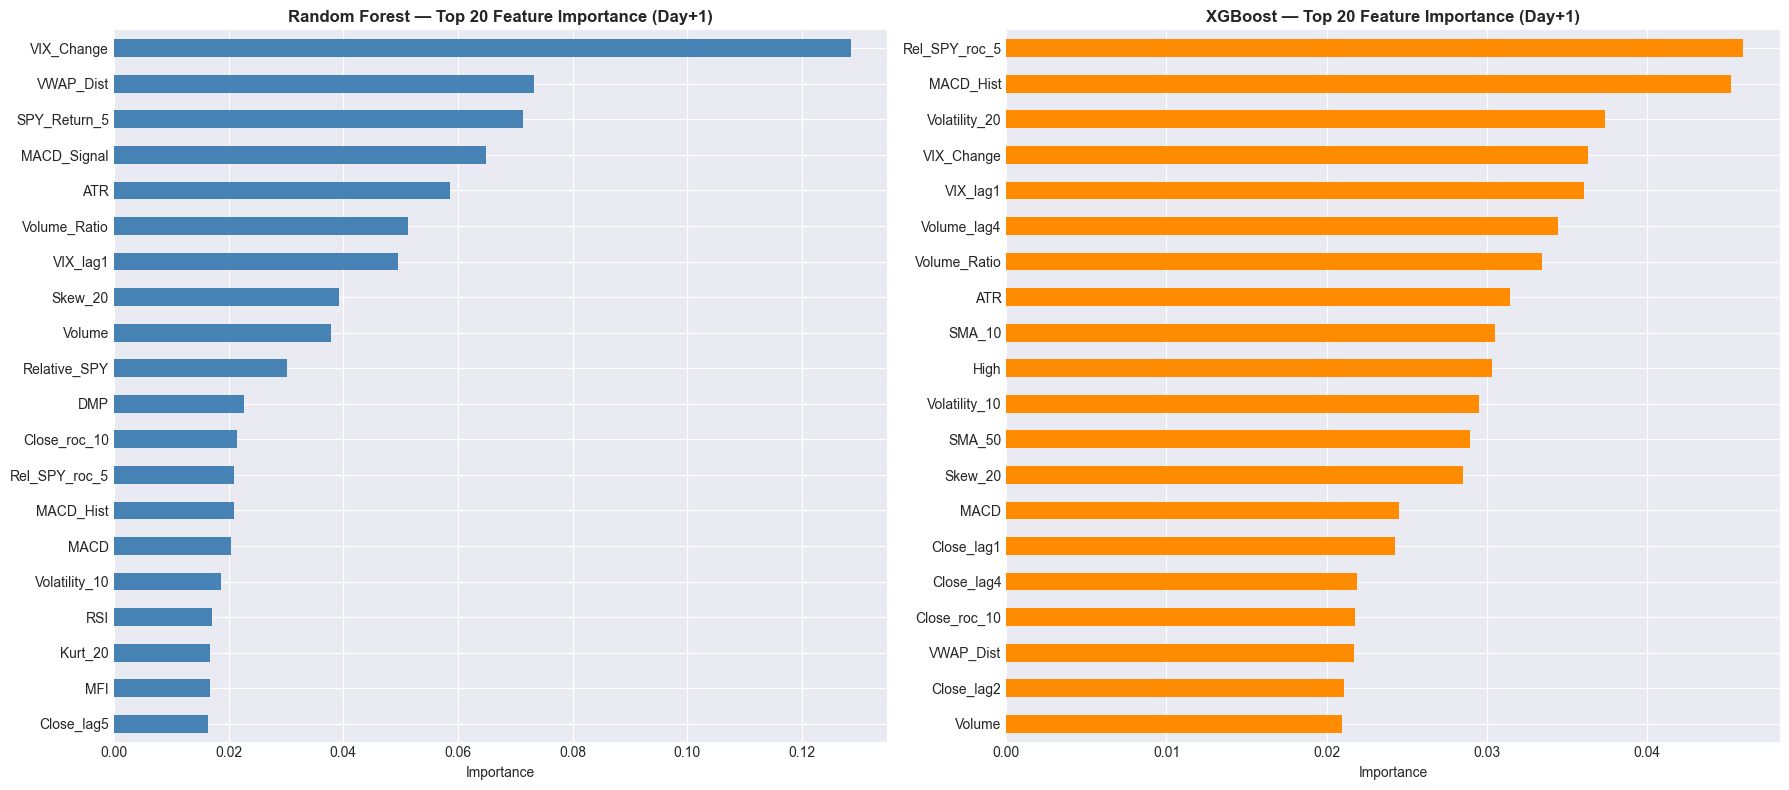

In [17]:
# ── Feature Importance (Random Forest & XGBoost) ─────────────────────────────

fig, axes = plt.subplots(1, 2 if XGB_AVAILABLE else 1,
                          figsize=(18 if XGB_AVAILABLE else 10, 8))
if not XGB_AVAILABLE:
    axes = [axes]

# RF importance — Day+1 model
rf_model = trained[1]['RF']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True).tail(20)
importances.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest — Top 20 Feature Importance (Day+1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance')

if XGB_AVAILABLE:
    xgb_model = trained[1]['XGBoost']
    xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True).tail(20)
    xgb_imp.plot.barh(ax=axes[1], color='darkorange')
    axes[1].set_title('XGBoost — Top 20 Feature Importance (Day+1)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()


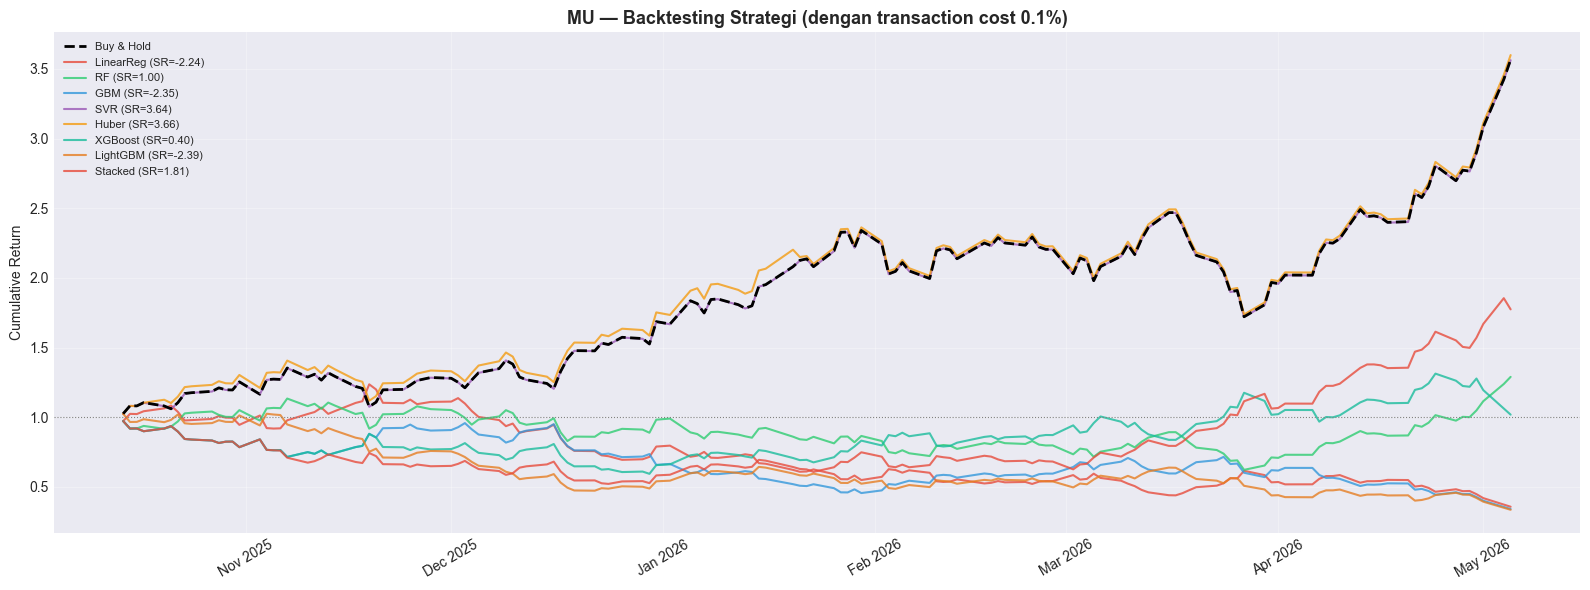


Backtest Summary (tc=0.1%):
Strategy        Total Ret   Sharpe    MaxDD
--------------------------------------------
Buy & Hold         256.6%     3.64   -30.3%
LinearReg          -64.2%    -2.24   -71.0%
RF                  29.0%     1.00   -45.1%
GBM                -65.8%    -2.35   -64.8%
SVR                256.3%     3.64   -30.3%
Huber              260.0%     3.66   -30.3%
XGBoost              1.9%     0.40   -38.9%
LightGBM           -66.4%    -2.39   -67.2%
Stacked             77.5%     1.81   -46.3%


In [18]:
# ── Backtesting with Transaction Costs ───────────────────────────────────────

TC = 0.001  # 0.1% transaction cost per trade (beli + jual)

y_d1_test   = test_df['Target_Return_D1'].values
test_dates  = test_df.index

fig, ax = plt.subplots(figsize=(16, 6))

# Buy & Hold baseline
bh_cum = np.cumprod(1 + y_d1_test)
ax.plot(test_dates, bh_cum, color='black', linewidth=2, linestyle='--', label='Buy & Hold', zorder=5)

colors_bt = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#1abc9c', '#e67e22']
all_names  = list(trained[1].keys()) + ['Stacked']
all_preds  = {n: test_preds[1][n] for n in trained[1]}
all_preds['Stacked'] = stacked_test[1]

bt_stats = {}
for i, name in enumerate(all_names):
    signal    = np.sign(all_preds[name])
    # Transaction cost: dikenakan setiap kali posisi berubah
    pos_change = np.diff(np.concatenate([[0], signal]))
    cost       = np.abs(pos_change) * TC
    ret_net    = signal * y_d1_test - cost
    cum_net    = np.cumprod(1 + ret_net)
    sr         = sharpe_ratio(ret_net)
    mdd        = max_drawdown(cum_net)
    total_ret  = cum_net[-1] - 1
    bt_stats[name] = {'Sharpe': sr, 'MaxDD': mdd, 'TotalReturn': total_ret}
    ax.plot(test_dates, cum_net, color=colors_bt[i % len(colors_bt)],
            linewidth=1.5, alpha=0.8, label=f'{name} (SR={sr:.2f})')

ax.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
ax.set_title(f'{TICKER} — Backtesting Strategi (dengan transaction cost {TC*100:.1f}%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Return')
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f'\nBacktest Summary (tc={TC*100:.1f}%):')
bh_sr    = sharpe_ratio(y_d1_test)
bh_mdd   = max_drawdown(np.cumprod(1 + y_d1_test))
bh_total = np.cumprod(1 + y_d1_test)[-1] - 1
print(f'{"Strategy":<14} {"Total Ret":>10} {"Sharpe":>8} {"MaxDD":>8}')
print('-' * 44)
print(f'{"Buy & Hold":<14} {bh_total*100:>9.1f}% {bh_sr:>8.2f} {bh_mdd*100:>7.1f}%')
for name, s in bt_stats.items():
    print(f'{name:<14} {s["TotalReturn"]*100:>9.1f}% {s["Sharpe"]:>8.2f} {s["MaxDD"]*100:>7.1f}%')


In [19]:
# ── 5-Day Direct Prediction (tanpa rekursif) ─────────────────────────────────
# Setiap model per horizon (D1–D5) langsung dijalankan pada baris data terakhir

last_date  = df.index[-1]
last_close = float(df['Close'].iloc[-1])

# Baris terakhir yang lengkap
last_row     = model_df.iloc[-1:][FEATURES].values
last_row_sc  = scaler.transform(last_row)

pred_dates  = pd.bdate_range(start=last_date + timedelta(days=1), periods=5)
pred_table  = pd.DataFrame({'Date': pred_dates.date})

# Base model preds per horizon
direct_preds = {}   # {name: [D1_price, D2_price, ...]}
for name in trained[1]:
    prices = []
    for h in range(1, 6):
        m = trained[h][name]
        r = m.predict(last_row_sc if name == 'SVR' else last_row)[0]
        prices.append(last_close * (1 + r))
    direct_preds[name] = prices
    pred_table[name] = [f'${p:.2f}' for p in prices]

# Stacked ensemble
stacked_prices = []
for h in range(1, 6):
    base_outs = np.array([
        trained[h][n].predict(last_row_sc if n == 'SVR' else last_row)[0]
        for n in trained[h]
    ]).reshape(1, -1)
    r_stacked = stacked_models[h].predict(base_outs)[0]
    stacked_prices.append(last_close * (1 + r_stacked))

# Quantile bounds
q10_prices, q90_prices = [], []
for h in range(1, 6):
    # Re-fit quantile on full train and predict last row
    y_tr_h = train_df[f'Target_Return_D{h}'].values
    q10m = QuantileRegressor(quantile=0.10, alpha=0.1, solver='highs').fit(X_train, y_tr_h)
    q90m = QuantileRegressor(quantile=0.90, alpha=0.1, solver='highs').fit(X_train, y_tr_h)
    q10_prices.append(last_close * (1 + q10m.predict(last_row)[0]))
    q90_prices.append(last_close * (1 + q90m.predict(last_row)[0]))

pred_table['Stacked'] = [f'${p:.2f}' for p in stacked_prices]
pred_table['Q10']     = [f'${p:.2f}' for p in q10_prices]
pred_table['Q90']     = [f'${p:.2f}' for p in q90_prices]

print(f'5-Day Direct Prediction for {TICKER}')
print(f'Last Close: ${last_close:.2f} ({last_date.date()})')
print('=' * 120)
print(pred_table.to_string(index=False))

print('\nStacked Ensemble % Change:')
for i, p in enumerate(stacked_prices):
    chg  = (p / last_close - 1) * 100
    sign = '+' if chg >= 0 else ''
    print(f'  Day+{i+1} ({pred_dates[i].date()}): ${p:.2f}  ({sign}{chg:.2f}%)')
    print(f'         90% CI: [${q10_prices[i]:.2f} — ${q90_prices[i]:.2f}]')


5-Day Direct Prediction for MU
Last Close: $766.58 (2026-05-12)
      Date LinearReg      RF     GBM     SVR   Huber XGBoost LightGBM Stacked     Q10     Q90
2026-05-13   $706.67 $768.89 $756.34 $770.97 $768.24 $765.57  $757.52 $766.52 $635.94 $908.50
2026-05-14   $677.11 $767.75 $775.64 $772.59 $768.59 $754.31  $775.77 $766.25 $661.55 $907.23
2026-05-15   $663.05 $777.59 $789.40 $766.59 $770.27 $766.41  $780.33 $781.63 $626.73 $873.29
2026-05-18   $617.03 $771.95 $787.09 $761.12 $768.26 $777.03  $781.61 $796.85 $662.46 $873.00
2026-05-19   $724.64 $777.93 $774.97 $750.31 $771.85 $782.27  $785.42 $804.32 $662.26 $888.25

Stacked Ensemble % Change:
  Day+1 (2026-05-13): $766.52  (-0.01%)
         90% CI: [$635.94 — $908.50]
  Day+2 (2026-05-14): $766.25  (-0.04%)
         90% CI: [$661.55 — $907.23]
  Day+3 (2026-05-15): $781.63  (+1.96%)
         90% CI: [$626.73 — $873.29]
  Day+4 (2026-05-18): $796.85  (+3.95%)
         90% CI: [$662.46 — $873.00]
  Day+5 (2026-05-19): $804.32  (+4.9

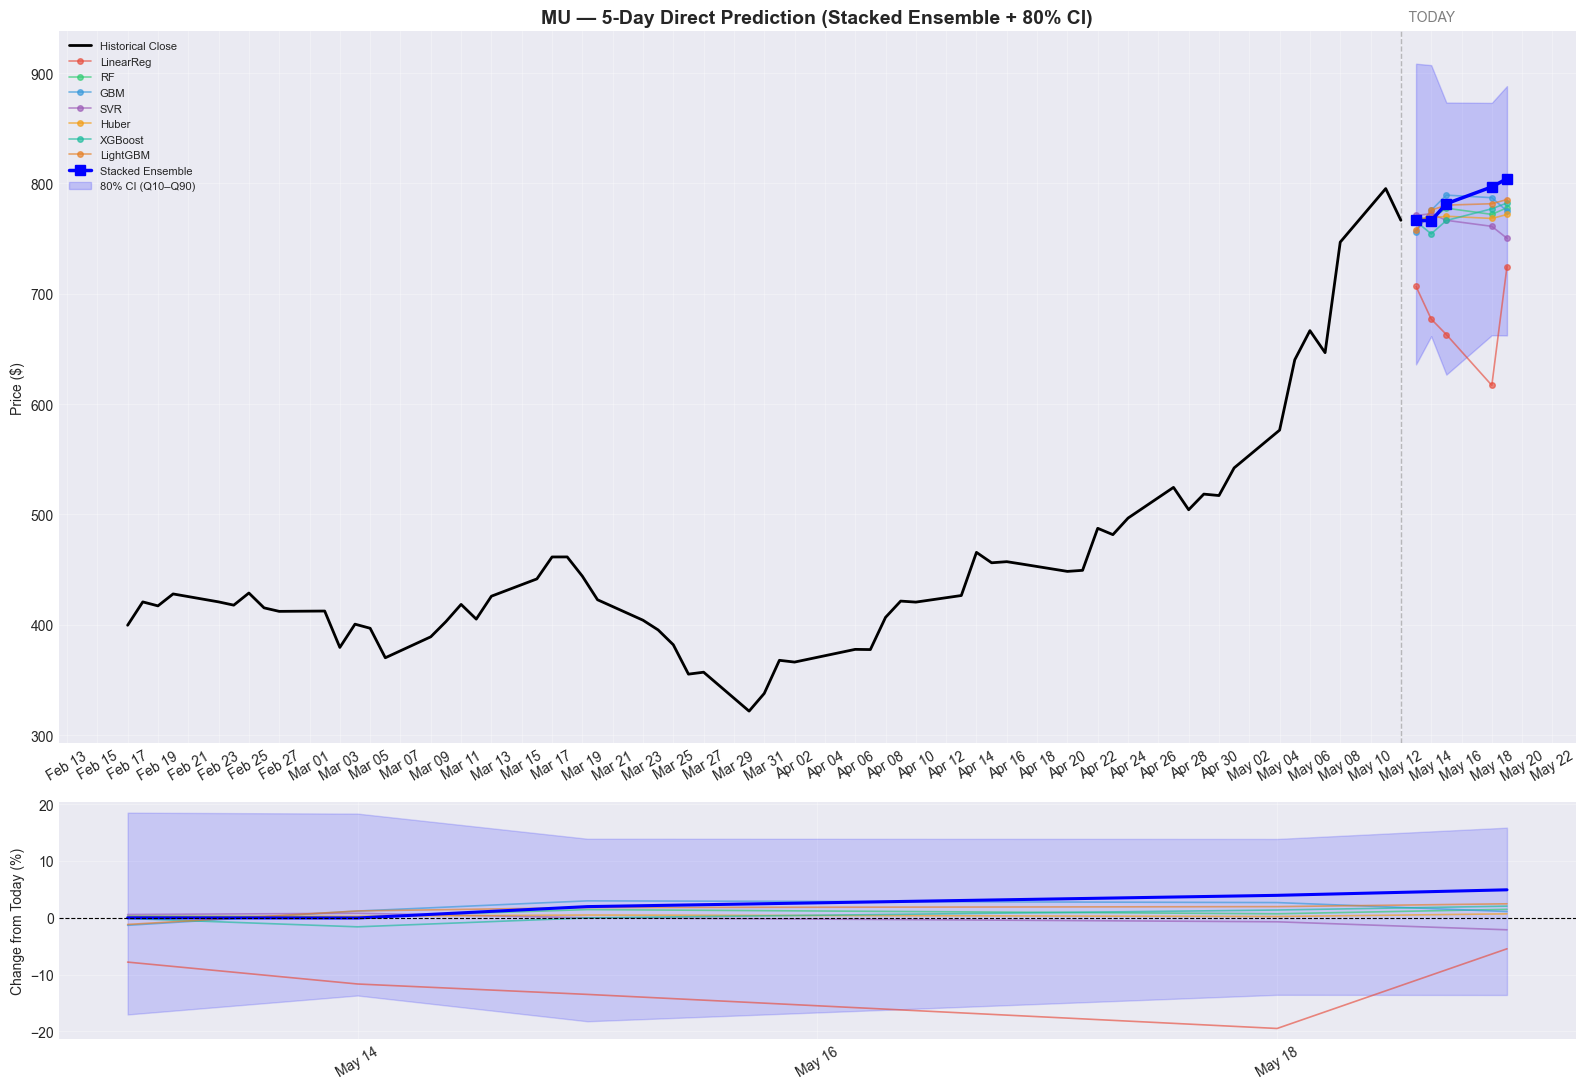

In [20]:
# ── Visualization: Prediction + Uncertainty Bands ────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(16, 11),
                          gridspec_kw={'height_ratios': [3, 1]})
ax, ax2 = axes

# Historical
hist = df['Close'].iloc[-60:]
ax.plot(hist.index, hist, color='black', linewidth=2, label='Historical Close', zorder=5)

# Per-model predictions
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#1abc9c', '#e67e22']
for i, (name, prices) in enumerate(direct_preds.items()):
    ax.plot(pred_dates, prices, color=colors[i % len(colors)],
            linewidth=1.2, marker='o', markersize=4, alpha=0.65, label=name)

# Stacked ensemble
ax.plot(pred_dates, stacked_prices, color='blue', linewidth=2.5,
        marker='s', markersize=7, label='Stacked Ensemble', zorder=6)

# Quantile uncertainty band
ax.fill_between(pred_dates, q10_prices, q90_prices,
                alpha=0.18, color='blue', label='80% CI (Q10–Q90)')

# TODAY line
ax.axvline(x=last_date, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(last_date, 1.01, '  TODAY', color='gray', fontsize=10,
        transform=ax.get_xaxis_transform(), va='bottom')

ax.set_title(f'{TICKER} — 5-Day Direct Prediction (Stacked Ensemble + 80% CI)', fontsize=14, fontweight='bold')
ax.set_ylabel('Price ($)')
ax.legend(loc='best', fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# % change panel
for i, (name, prices) in enumerate(direct_preds.items()):
    pct = [(p / last_close - 1) * 100 for p in prices]
    ax2.plot(pred_dates, pct, color=colors[i % len(colors)], linewidth=1.2, alpha=0.65, label=name)
stk_pct = [(p / last_close - 1) * 100 for p in stacked_prices]
ax2.plot(pred_dates, stk_pct, color='blue', linewidth=2.2, label='Stacked')
ax2.fill_between(pred_dates,
                  [(p / last_close - 1) * 100 for p in q10_prices],
                  [(p / last_close - 1) * 100 for p in q90_prices],
                  alpha=0.15, color='blue')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Change from Today (%)')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()
